In [43]:
import typing
import utils
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [19]:
basedir = "../5_task_transfer"

In [20]:
df = utils.subset_data(
    basedir=basedir,
    index={
        # "model.from_pretrained": lambda x: x is not None,
        "dataset.concurrent_reg": lambda x: x == 5,
    },
)
df.sample(5)

,Unnamed: 0,epoch,run_id,step,_step,_runtime,best_val_acc,best_val_epoch,epoch_step,cumAUC,...,ignore_prob,heldout_items,concurrent_reg,same_diff_prob,concurrent_items,role_n_congruence,heldout_items_per_reg,create_dataset_and_exit,local_split_set_control,global_split_set_control
273,273,27,hopeful-sweep-3,10547.0,10746,6376.443436,0.0,26.0,0.0,15.990050,...,0.5,0,5,0.5,4,0,15,False,NaN,NaN
481,481,48,eager-sweep-3,18750.0,19104,6943.257452,0.0,47.0,0.0,34.853160,...,0.5,0,5,0.5,4,0,15,False,NaN,NaN
358,358,35,summer-sweep-10,13672.0,13930,5757.504302,0.0,34.0,0.0,25.225050,...,0.5,0,5,0.5,4,0,15,False,NaN,NaN
445,445,44,magic-sweep-5,17188.0,17512,5655.946990,0.0,43.0,0.0,36.909255,...,0.5,0,5,0.5,4,0,15,False,NaN,NaN
293,293,29,glowing-sweep-6,11329.0,11542,4510.547426,0.0,21.0,0.0,27.115620,...,0.5,0,5,0.5,4,0,15,False,NaN,NaN


In [21]:
td_prob_info = utils.extract_sweep_properties(
    utils.gather_sweeps(basedir), ["dataset.td_prob"]
)
[*td_prob_info.items()][0]

('tm9bckt9', {'dataset.td_prob': 0})

In [22]:
from typing import Literal


def get_pretraining_condition(row) -> Literal["REF-BACK", "N-BACK", "NA"]:
    this_pretraining = row["from_pretrained"]
    if isinstance(this_pretraining, str):
        pretraining_sweep_id = this_pretraining.split("/")[1]
        return (
            "REF-BACK"
            if td_prob_info[pretraining_sweep_id]["dataset.td_prob"] == 0
            else "N-BACK"
        )
    return "NA"


# map td_prob_info to `df` as a new column called 'pretraining_condition'
df["pretraining_condition"] = df.apply(
    get_pretraining_condition,
    axis=1,
)

df.loc[df["from_pretrained"] == None]["pretraining_condition"] = "NA"

<Axes: xlabel='epoch', ylabel='eval_acc'>

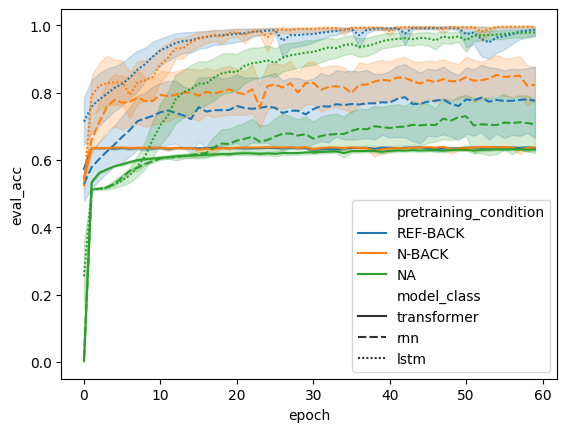

In [23]:
sns.lineplot(
    df, x="epoch", y="eval_acc", hue="pretraining_condition", style="model_class"
)

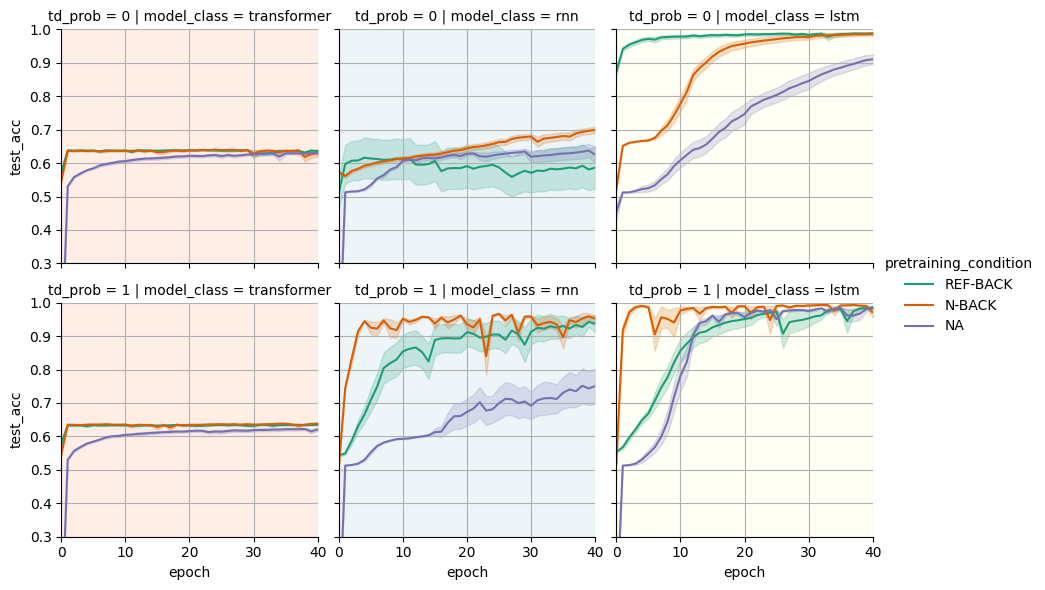

In [87]:
def shuffled(collection: typing.Collection):
    import random

    return random.sample(collection, len(collection))
    # Define a mapping of model_class to colors


g = sns.FacetGrid(
    df,
    col="model_class",
    row="td_prob",
    hue="pretraining_condition",
    sharex=True,
    sharey=True,
    palette=sns.color_palette(["#1b9e77", "#d95f02", "#7570b3"]),
)
g.map_dataframe(
    sns.lineplot,
    x="epoch",
    y="test_acc",
    alpha=1,
    errorbar="se",
)

alpha = 0.15
background_colors = dict(
    zip(
        df.model_class.unique(),
        zip(
            shuffled(["#fc8d59", "#ffffbf", "#91bfdb"]),
            [alpha] * 10,
        ),
    )
)

# Apply background color to each subplot based on model_class


g.add_legend()
for ax in g.axes.flat:
    ax.set_ylim(0.3, 1)
    ax.set_xlim(0, 40)
    ax.grid()

    model_class = ax.get_title().split(" | ")[1].split(" = ")[1]
    if model_class in background_colors:
        ax.set_facecolor(background_colors[model_class])

plt.show()